In [ ]:
pip install pandas


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd

In [6]:
df=pd.read_csv(r"C:\Users\Risho\Downloads\3.WineQT.csv")

In [7]:
print("dataset shape",df.shape)

dataset shape (1143, 13)


In [8]:
print("datatype: ",df.dtypes)
print("data: ",df.head())
print("description: ",df.describe(include='all'))

datatype:  fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object
data:     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0        

In [10]:
print("no of data missing: ",df.isnull().sum())

no of data missing:  fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [12]:
#Using NumPy, calculate the mean, median, standard deviation, and quartiles for each numerical feature. 
import numpy as np
#select the columns with numerical values
numerical=df.select_dtypes(include=[np.number])
print("mean is:\n ",numerical.mean())
print("median is:\n",numerical.median())
print("standard dev is: \n",numerical.std())
print("the quarantile range is: \n",numerical.quantile([0.25,0.5,0.75]))

mean is:
  fixed acidity             8.311111
volatile acidity          0.531339
citric acid               0.268364
residual sugar            2.532152
chlorides                 0.086933
free sulfur dioxide      15.615486
total sulfur dioxide     45.914698
density                   0.996730
pH                        3.311015
sulphates                 0.657708
alcohol                  10.442111
quality                   5.657043
Id                      804.969379
dtype: float64
median is:
 fixed acidity             7.90000
volatile acidity          0.52000
citric acid               0.25000
residual sugar            2.20000
chlorides                 0.07900
free sulfur dioxide      13.00000
total sulfur dioxide     37.00000
density                   0.99668
pH                        3.31000
sulphates                 0.62000
alcohol                  10.20000
quality                   6.00000
Id                      794.00000
dtype: float64
standard dev is: 
 fixed acidity             1.747

In [21]:
#Create a correlation matrix using Pandas and visualize it using a heatmap in Matplotlib. 
#create confusion matrix
correlation_matrix=numerical.corr()
print("the correlation matrix is: ",correlation_matrix)

the correlation matrix is:                        fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.250728     0.673157   
volatile acidity          -0.250728          1.000000    -0.544187   
citric acid                0.673157         -0.544187     1.000000   
residual sugar             0.171831         -0.005751     0.175815   
chlorides                  0.107889          0.056336     0.245312   
free sulfur dioxide       -0.164831         -0.001962    -0.057589   
total sulfur dioxide      -0.110628          0.077748     0.036871   
density                    0.681501          0.016512     0.375243   
pH                        -0.685163          0.221492    -0.546339   
sulphates                  0.174592         -0.276079     0.331232   
alcohol                   -0.075055         -0.203909     0.106250   
quality                    0.121970         -0.407394     0.240821   
Id                        -0.275826         -0.007892    -0.13

In [ ]:
pip install matplotlib


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 3.3 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.1 MB 3.2 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.1 MB 2.9 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.1 MB 3.0 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 2.8 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 2.6 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 2.5 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.1 MB 2.5 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 2.4 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.1 MB 2.4 MB/s eta 0:00:02
   --------------------------- ------------ 5.5/8.1 MB 2.3 MB/s eta 0:00:02
   -----------------------


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


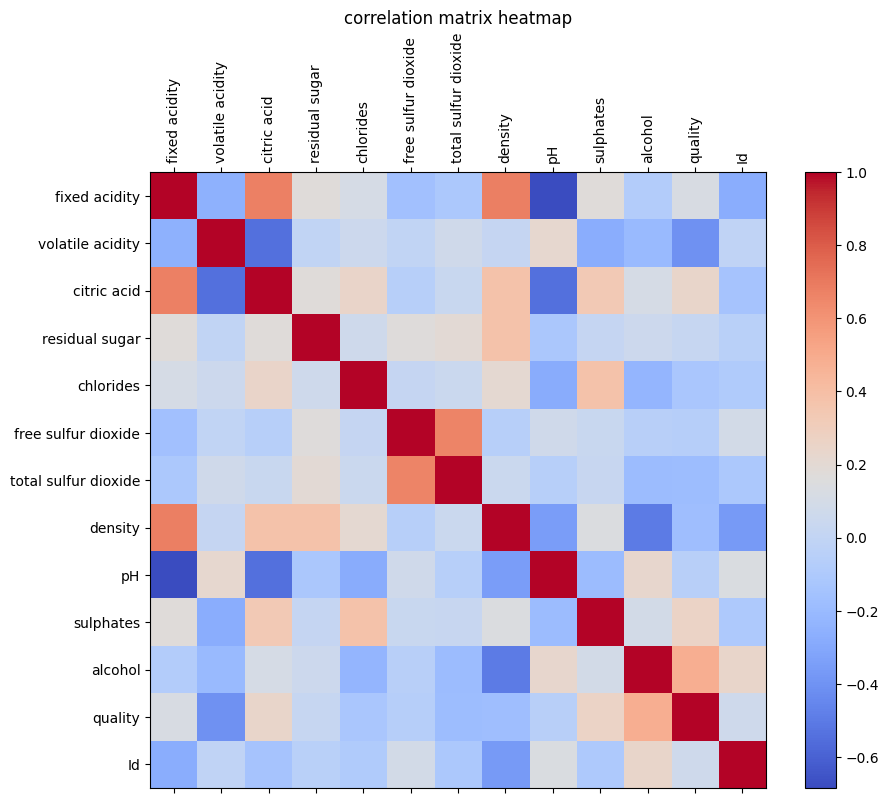

In [30]:
#plot heatmap with mathplotlib
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(10,8))
cax=ax.matshow(correlation_matrix,cmap='coolwarm')
plt.colorbar(cax)
ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=90)
ax.set_yticklabels(correlation_matrix.columns)
plt.title("correlation matrix heatmap")
plt.show()


In [31]:
target_corr=correlation_matrix['quality'].drop('quality')
top=target_corr.abs().sort_values(ascending=False).head(5)
print("top 5: ",top)

top 5:  alcohol                 0.484866
volatile acidity        0.407394
sulphates               0.257710
citric acid             0.240821
total sulfur dioxide    0.183339
Name: quality, dtype: float64


<Figure size 1000x1000 with 0 Axes>

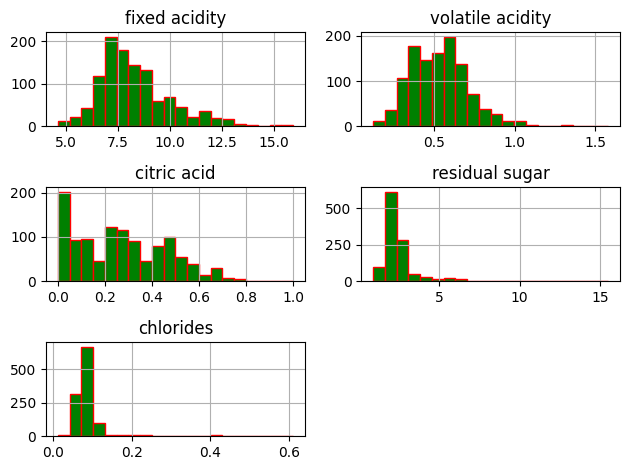

In [ ]:
#Create histograms for at least 5 numerical features to understand their distribution. 
#our numerical is a dataframe and not column name.hence extract col names and then limit to first 5

features=numerical.columns.tolist()[:5]
plt.figure(figsize=(10,10))
df[features].hist(bins=20,color='green',edgecolor='red')
plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

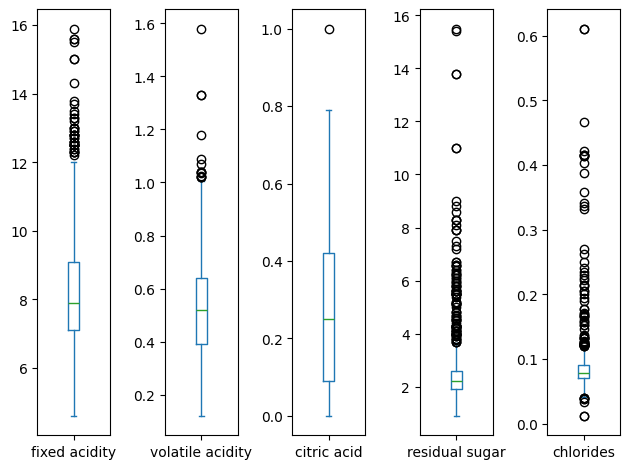

In [40]:
#Create box plots for the same 5 features to identify outliers. 
#our numerical is a dataframe and not column name.hence extract col names and then limit to first 5

features=numerical.columns.tolist()[:5]
plt.figure(figsize=(10,10))
df[features].plot(kind='box',subplots=True,layout=(1,5))
plt.tight_layout()
plt.show()

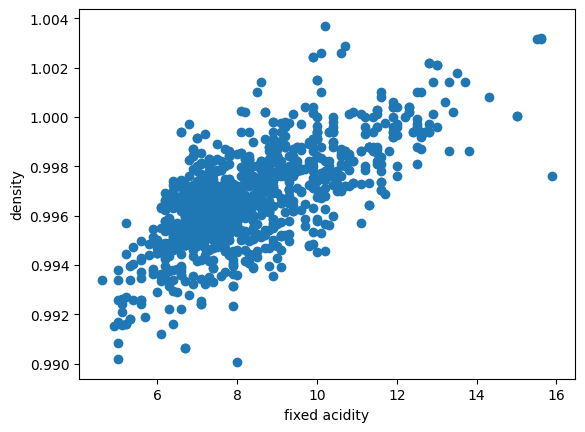

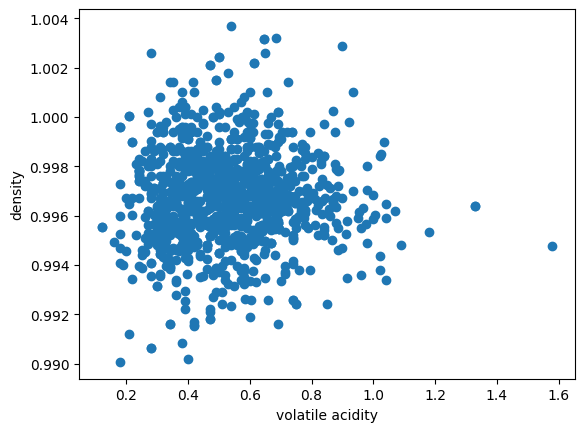

In [42]:
#Visualize the relationship between the target variable and a few key features using scatter plots or bar charts. 
for i in features[:2]:
    plt.scatter(df[i],df['density'])
    plt.xlabel(i)
    plt.ylabel('density')
    plt.show()


In [44]:
#adding new feature from existing features by combining them
df['total_acidity']=df['fixed acidity']+df['volatile acidity']

Explain the rationale behind creating these new features.
combines fixed acidity and volatile acidity to represent overall acidity.provides a more complete view of the wine's acidity profile.reduces redundancy by merging correlated features.leaverages domain knowledge from wine maKING.MAY IMPROVE MODEL PERFORMANCE BY STRENGTHENING CORRELATION WITH WINE QUALITY.


INSIGHTS AND CONCLUSION:
key findings:
No missing values found.
Alcohol and citric acid positively correlate with quality.
volatile acidity negatively affects quality.
new feature total_acidity captures overall acidity impact.
Implications:
key features like alcohol and total_acidity can predict quality.
Helps in quality control and consistency of wine.
Further investigation:
Try predictive models for quality.
Testy interaction or polynomial features.
Apply feature selection for optimization.